In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [28]:
def read_collision_data_complete(filename):
    
    with open(filename, 'r') as file:
        lines = file.readlines()

    sections = {}
    data_rows = []
    similarity_values = []
    snp_rate = []

    for line in lines:
        line = line.strip()
        if not line:
            continue
            
        if line.startswith(':1:'):
            sections['test_name'] = line[3:].strip()
        elif line.startswith(':2:'):
            sections['column_headers'] = line[3:].strip().split(',')
        elif line.startswith(':3:'):
            line_content = line[3:].strip()
            line_parts = line_content.split(',')
            sections['Hashname'] = line_parts[0].strip()
            sections['SequenceLength'] = int(line_parts[1].strip())
            sections['TokenLength'] = int(line_parts[2].strip())
            sections['Distance_Metric'] = int(line_parts[3].strip())
        elif line.startswith(':3.1:'):
            line_content = line[5:].strip()
            line_parts = line_content.split(',')
            sections['SubseqHash_k'] = line_parts[0].strip()
            sections['SubseqHash_d'] = int(line_parts[1].strip())
        elif line.startswith(':4:'):
            line_content = line[3:].strip()
            similarity_values = [float(x.strip()) for x in line_content.split(',')]
            sections['similarity_values'] = similarity_values
        elif line.startswith(':5:'):
            line_content = line[3:].strip()
            snp_rate = [float(x.strip()) for x in line_content.split(',')]
            sections['snp_rate'] = snp_rate
        elif line.startswith(':6:'):
            line_content = line[3:].strip()
            collision_rates = [float(x.strip()) for x in line_content.split(',')]
            sections['collision_rates'] = collision_rates
            
            # Create data row
            row_data = {
                'test_name': sections.get('test_name', ''),
                'hashname': sections.get('Hashname', ''),
                'sequencelength': sections.get('SequenceLength', 0),
                'tokenlength': sections.get('TokenLength', 0),
                'similarity_values': similarity_values,
                'snp_rate': snp_rate,
                'collision_rates': collision_rates,
                'SubseqHash_k': sections.get('SubseqHash_k', 0),
                'SubseqHash_d': sections.get('SubseqHash_d', 0)

            }
            data_rows.append(row_data)
    
    return sections, pd.DataFrame(data_rows)


In [29]:
# sections,df =  read_collision_data_complete("/home/dynamics/bikram/BioHasher/results/collisionResults_OneBaseSamplingHash-32.csv")
# sections,df =  read_collision_data_complete("/home/dynamics/bikram/BioHasher/results/collisionResults_MinHash-32.csv")
# sections,df =  read_collision_data_complete("/home/dynamics/bikram/BioHasher/results/collisionResults_SimHash-Ang-32.csv")
sections,df =  read_collision_data_complete("/home/dynamics/bikram/BioHasher/results/collisionResults_SubseqHash-64.csv")
similarity = "Edit Similarity"


In [30]:
# df.drop(df[df['sequencelength'] == 40].index, inplace=True)
# df

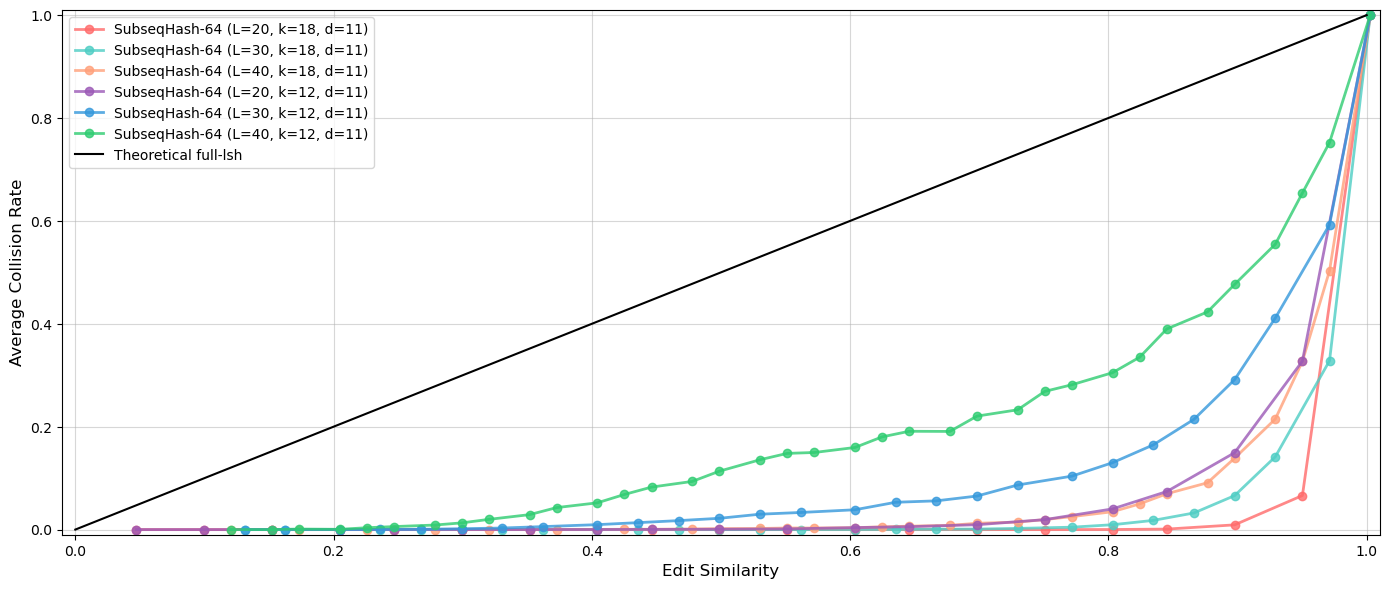

In [31]:
# Define colors for different rows
colors = ['#FF6B6B', '#4ECDC4', '#FFA07A', '#9B59B6', '#3498DB', '#2ECC71', '#E74C3C', '#1ABC9C']

# Create single figure
plt.figure(figsize=(14, 6))


name =""

for idx, row in df.iterrows():
    x_values = np.array(row['similarity_values'])
    y_values = np.array(row['collision_rates'])
    
    # Define bins
    num_bins = 100
    bin_edges = np.linspace(0, 1.05, num_bins + 1)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
    # Compute mean for each bin
    bin_means = []
    
    for i in range(num_bins):
        mask = (x_values >= bin_edges[i]) & (x_values < bin_edges[i + 1])
        if mask.sum() > 0:
            bin_means.append(np.mean(y_values[mask]))
        else:
            bin_means.append(np.nan)
    
    bin_means = np.array(bin_means)
    valid = ~np.isnan(bin_means)
    
    # Create label from row data
    label = f"{row['hashname']} (L={row['sequencelength']}, k={row['SubseqHash_k']}, d={row['SubseqHash_d']})"
    
    name = f"{row['hashname']}"
    
    # Plot this row with unique color
    plt.plot(
        bin_centers[valid],
        bin_means[valid],
        '-o',
        color=colors[idx % len(colors)],
        alpha=0.8,
        markersize=6,
        linewidth=2,
        label=label
    )
    # plt.plot(bin_centers, bin_means, 'o-', color=colors[idx % len(colors)], 
    #          alpha=0.8, markersize=6, linewidth=2, label=label)

# Ideal line
plt.plot([0, 1], [0, 1], color="black", linewidth=1.5, alpha=1, label="Theoretical full-lsh")

# Styling
plt.xlim(-0.01, 1.01)
plt.ylim(-0.01, 1.01)
plt.grid(visible=True, which="both", axis="both", alpha=0.5)
plt.xlabel(similarity, fontsize=12)
plt.ylabel('Average Collision Rate', fontsize=12)
plt.legend(loc='upper left', fontsize=10)
plt.tight_layout()

plt.savefig(f"{name}_binaveraged.png", dpi=600)
plt.show()

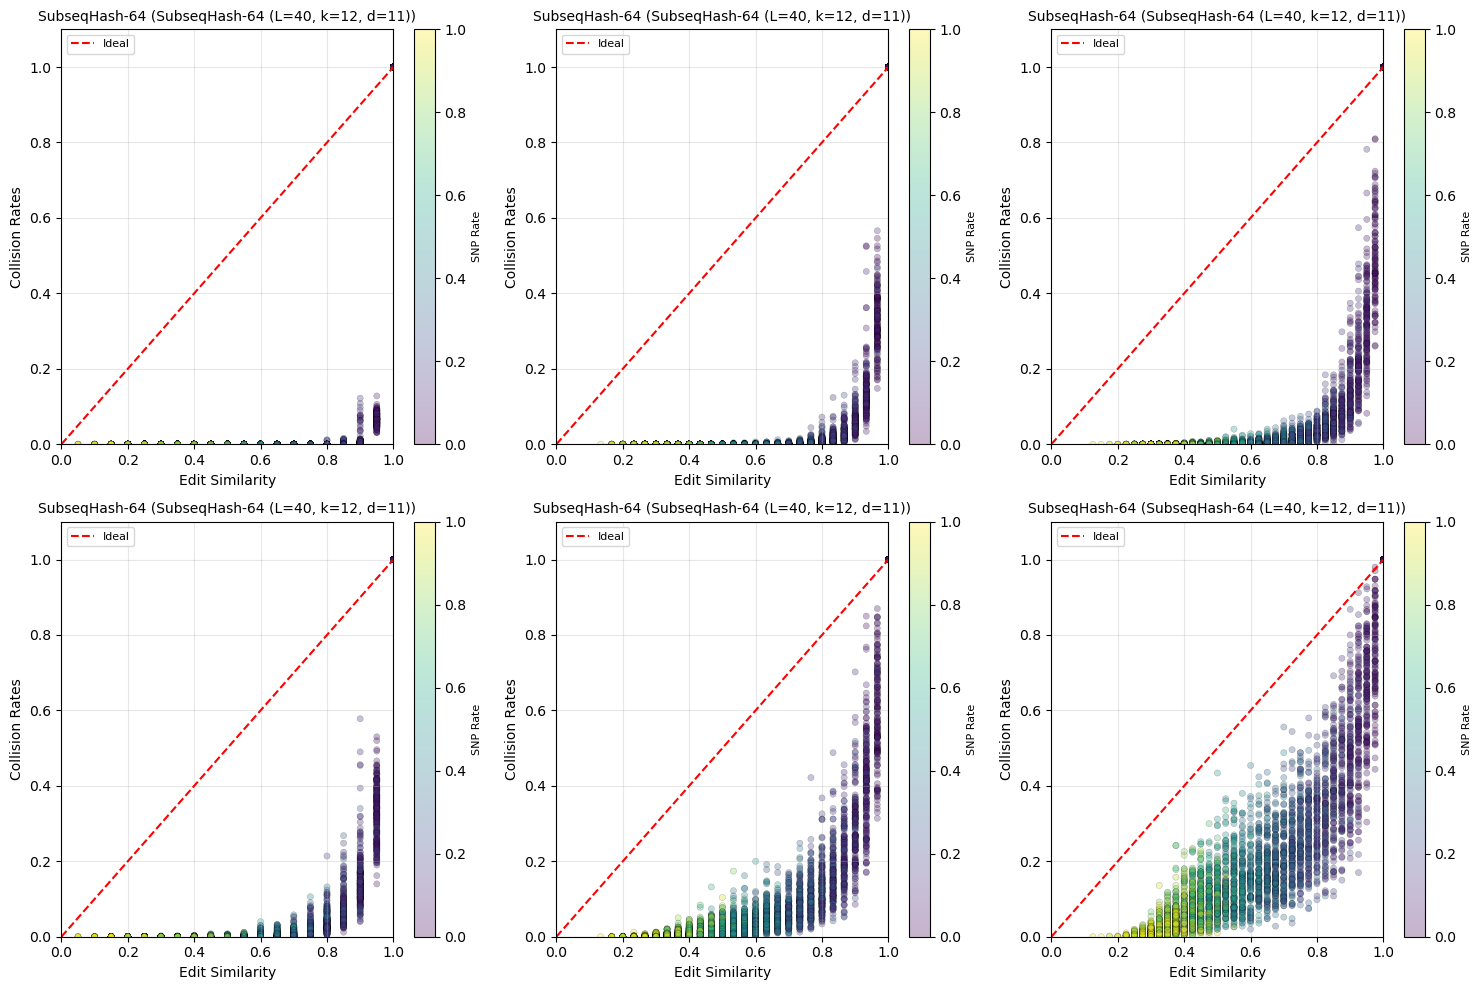

In [32]:

n_rows = len(df)
n_cols = 3
n_grid_rows = (n_rows + n_cols - 1) // n_cols  # Ceiling division

fig, axes = plt.subplots(nrows=n_grid_rows, ncols=n_cols, figsize=(15, 5 * n_grid_rows))
axes = axes.flatten()  # Flatten to 1D array for easy indexing

for idx, row in df.iterrows():
    ax = axes[idx]
    
    x_values = np.array(row['similarity_values'])
    y_values = np.array(row['collision_rates'])
    label_values = np.array(row['snp_rate'])
    
    # label = f"L={row['sequencelength']}, k={row['SubseqHash_k']}, d={row['SubseqHash_d']}"
    
    # Scatter plot with colorbar
    scatter = ax.scatter(x_values, y_values, c=label_values, cmap='viridis', 
                         alpha=0.3, edgecolors='black', linewidth=0.3, s=20)
    
    # Add colorbar for each subplot
    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label('SNP Rate', fontsize=8)
    
    # Ideal line
    ax.plot([0, 1], [0, 1], 'r--', linewidth=1.5, label='Ideal')
    
    # Axis settings
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1.1)
    ax.set_xlabel(similarity, fontsize=10)
    ax.set_ylabel('Collision Rates', fontsize=10)
    ax.set_title(f"{row['hashname']} ({label})", fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper left', fontsize=8)

# Hide unused subplots
for idx in range(len(df), len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
name = f"{row['hashname']}"
plt.savefig(f"{name}_snpcolor_multiplot.png", dpi=600)
plt.show()

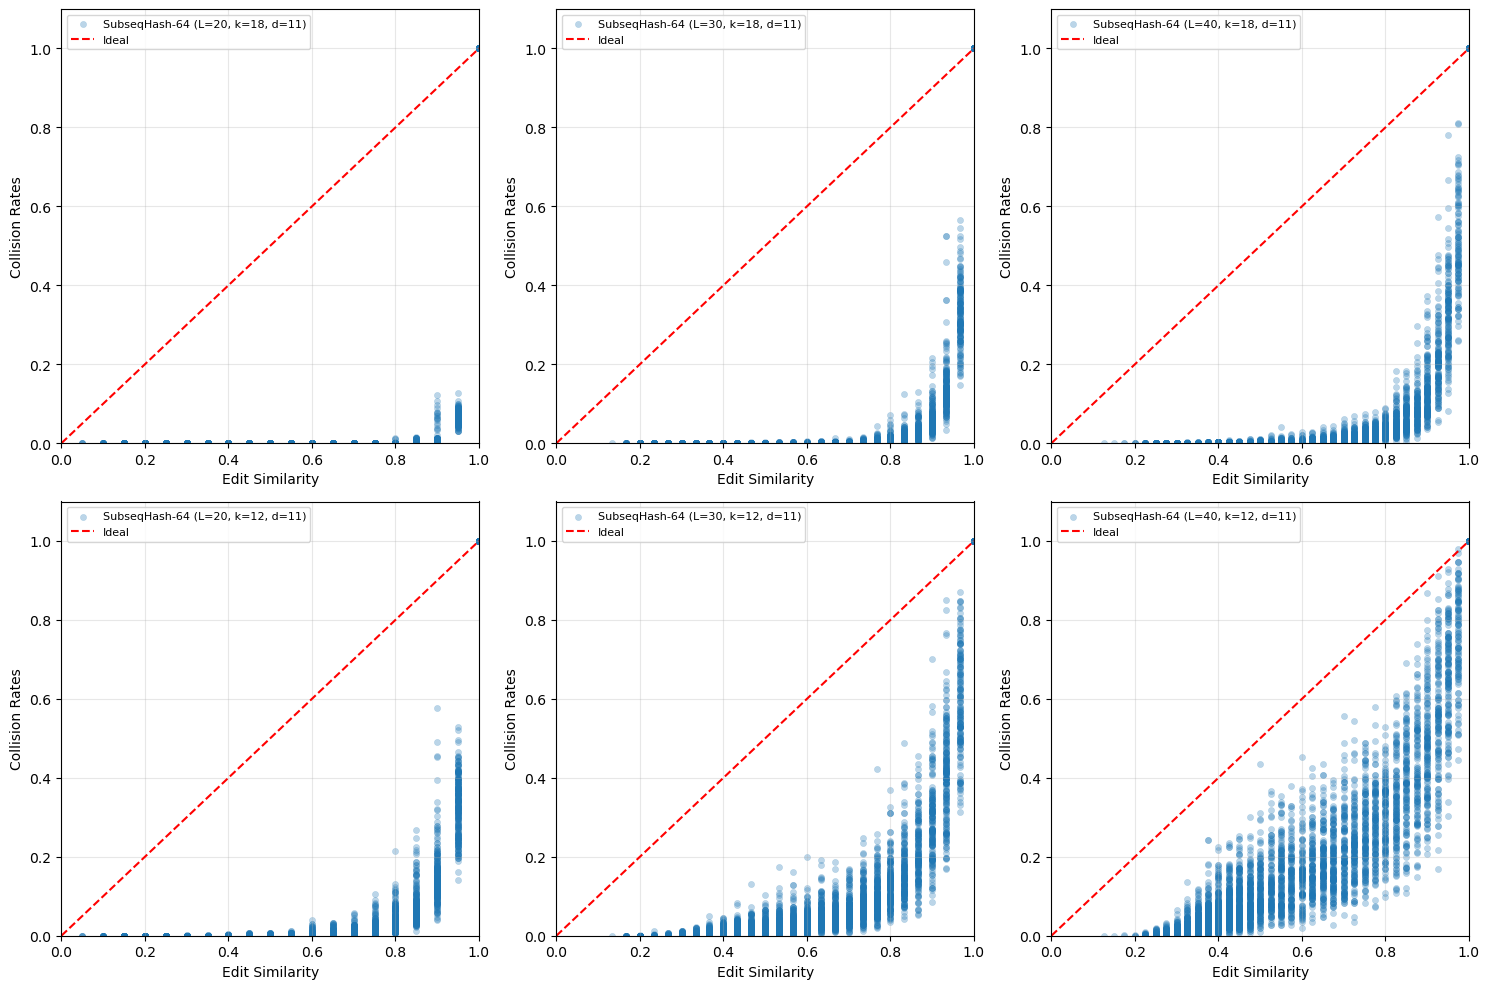

In [33]:

n_rows = len(df)
n_cols = 3
n_grid_rows = (n_rows + n_cols - 1) // n_cols  # Ceiling division

fig, axes = plt.subplots(nrows=n_grid_rows, ncols=n_cols, figsize=(15, 5 * n_grid_rows))
axes = axes.flatten()  # Flatten to 1D array for easy indexing

for idx, row in df.iterrows():
    ax = axes[idx]
    
    x_values = np.array(row['similarity_values'])
    y_values = np.array(row['collision_rates'])
    label_values = np.array(row['snp_rate'])
    
    label = f"{row['hashname']} (L={row['sequencelength']}, k={row['SubseqHash_k']}, d={row['SubseqHash_d']})"
    
    # Scatter plot with colorbar
    scatter = ax.scatter(x_values, y_values, label = label, 
                         alpha=0.3, linewidth=0.3, s=20)
    
    # Ideal line
    ax.plot([0, 1], [0, 1], 'r--', linewidth=1.5, label='Ideal')
    
    # Axis settings
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1.1)
    ax.set_xlabel(similarity, fontsize=10)
    ax.set_ylabel('Collision Rates', fontsize=10)
    # ax.set_title(f"{row['hashname']} ({label})", fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper left', fontsize=8)

# Hide unused subplots
for idx in range(len(df), len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
name = f"{row['hashname']}"
plt.savefig(f"{name}_singlecolor_multiplot.png", dpi=600)
plt.show()

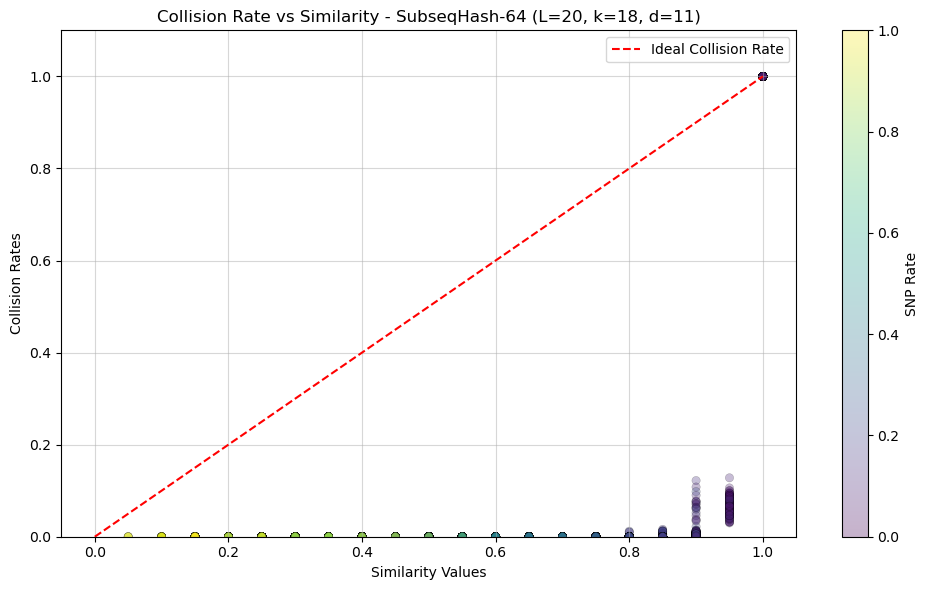

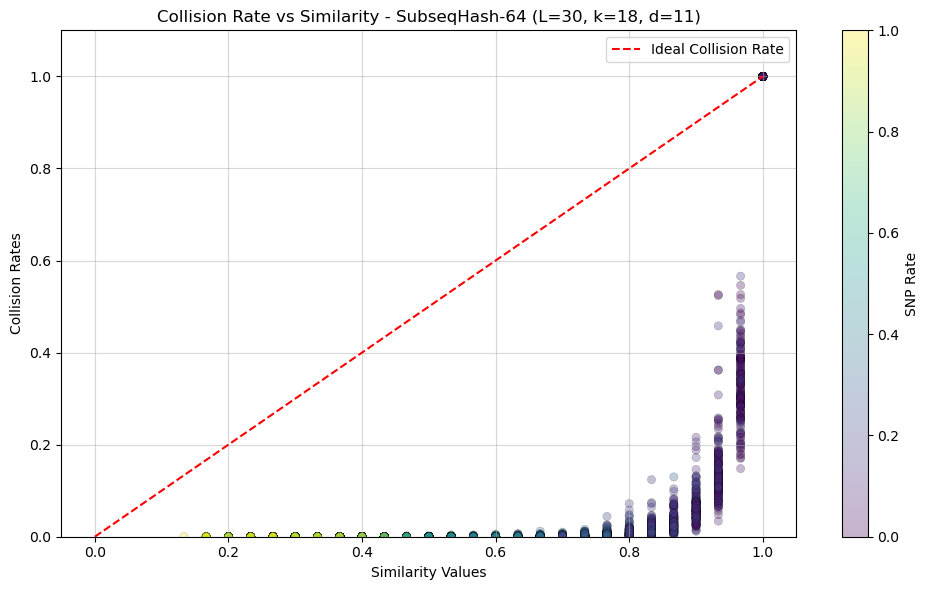

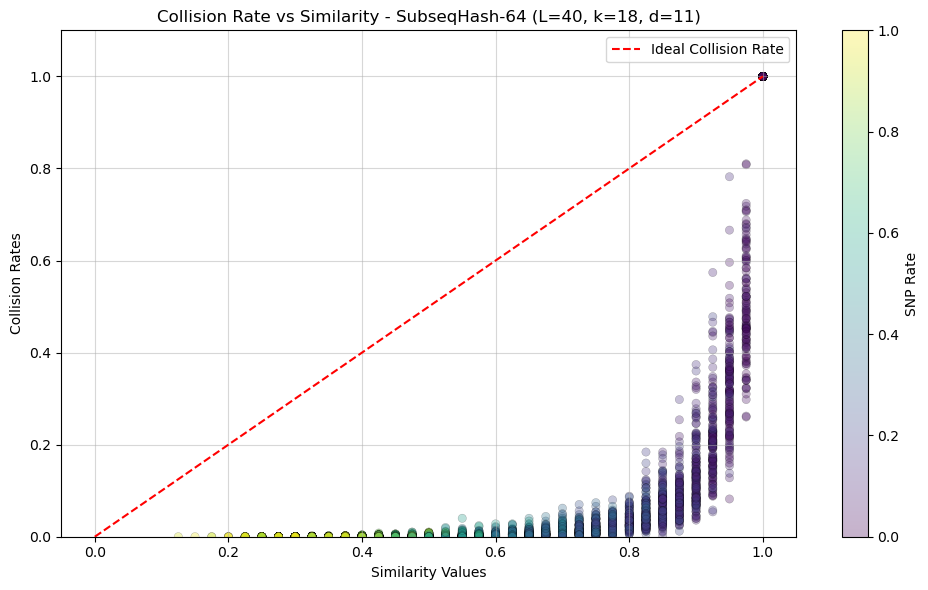

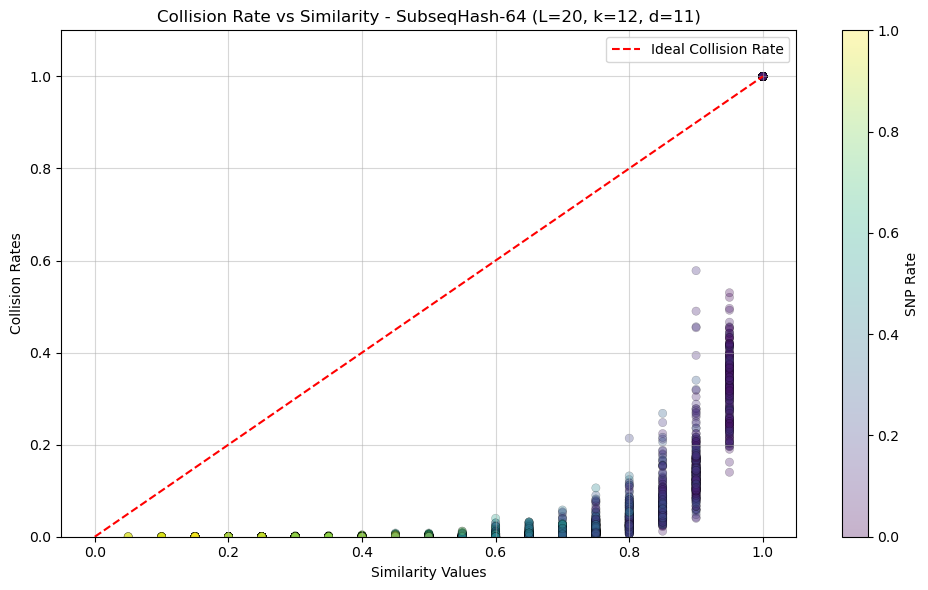

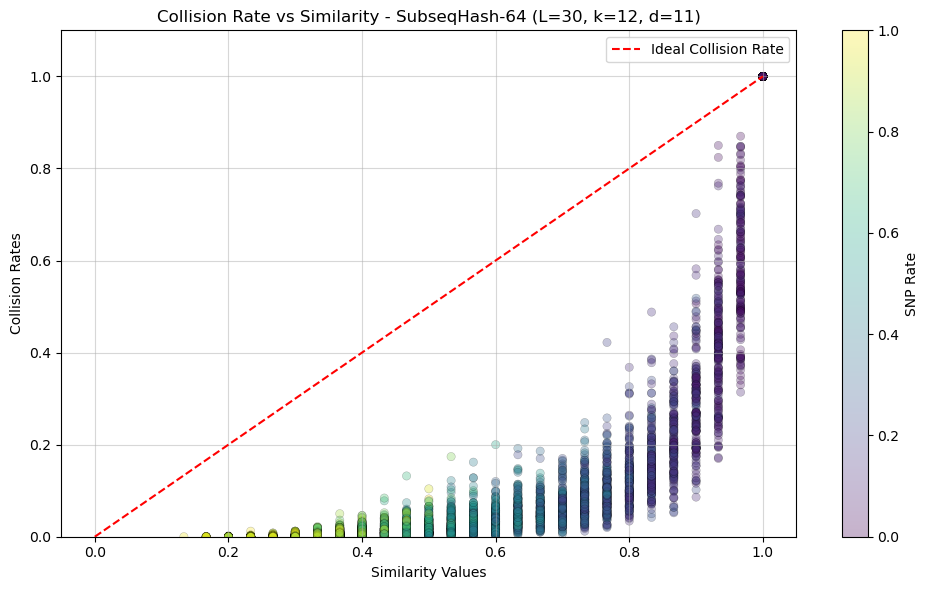

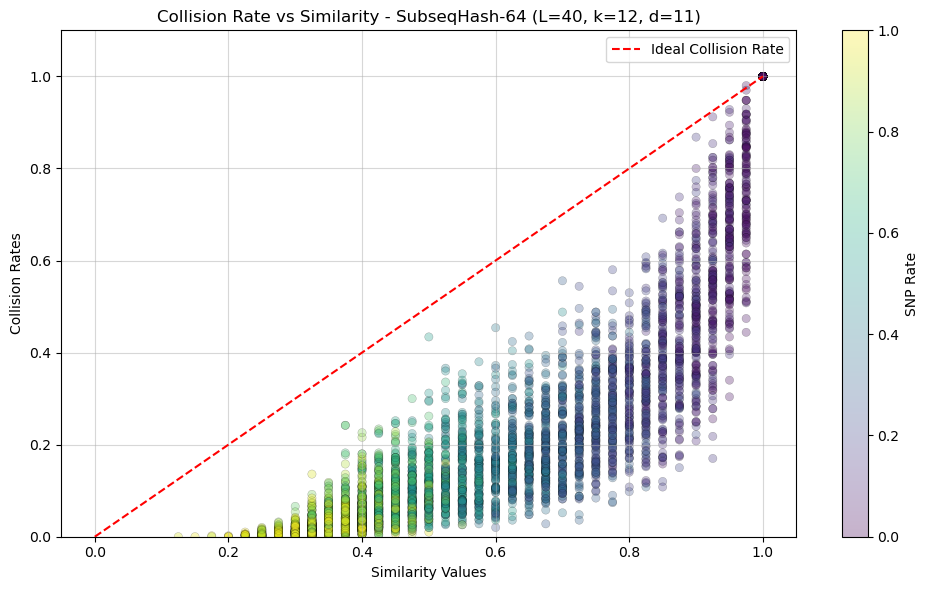

In [ ]:
fig, ax = plt.subplots(nrows=3, ncols=3)

for idx, row in df.iterrows():
    x_values = row['similarity_values']
    y_values = row['collision_rates']
    label_values = row['snp_rate']
    plt.figure(figsize=(10, 6))
    plt.ylim(0, 1.1)
    plt.grid(True, alpha=0.5)
    label = f"{row['hashname']} (L={row['sequencelength']}, k={row['SubseqHash_k']}, d={row['SubseqHash_d']})"

    plt.scatter(x_values, y_values, c=label_values, cmap='viridis', alpha=0.3, edgecolors='black', linewidth=0.3)
    plt.colorbar(label='SNP Rate')
    plt.xlabel('Similarity Values')
    plt.ylabel('Collision Rates')
    plt.title(f"Collision Rate vs Similarity - {label}")
    plt.plot([0, 1], [0, 1], 'r--', label='Ideal Collision Rate')
    plt.legend()
    
    plt.tight_layout()
    plt.show()

In [ ]:
for idx, row in df.iterrows():
    x_values = np.array(row['similarity_values'])
    y_values = np.array(row['collision_rates'])
    
    # Define bins (e.g., 20 bins from 0 to 1)
    num_bins = 100
    bin_edges = np.linspace(0, 1.1, num_bins + 1)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
    # Compute mean for each bin
    bin_means = []
    
    for i in range(num_bins):
        mask = (x_values >= bin_edges[i]) & (x_values < bin_edges[i + 1])
        if mask.sum() > 0:
            bin_means.append(np.mean(y_values[mask]))
        else:
            bin_means.append(np.nan)
    
    bin_means = np.array(bin_means)
    
    # Plot
    plt.figure(figsize=(12, 6))
    plt.ylabel(r"$\text{Average Collision rate}$", fontsize=15)
    plt.xlim(-0.01, 1.01)
    plt.ylim(-0.01, 1.01)
    plt.grid(visible=True, which="both", axis="both")
    
    # Plot average as line with markers
    plt.plot(bin_centers, bin_means, 'o-', color='#FF6B6B', alpha=1, markersize=8, linewidth=2, label='SubSeqHash1 (k=18,d=11)')
    
    # Ideal line
    # plt.plot([0, 1], [0, 1], 'r--', linewidth=2, label='Ideal Collision Rate')
    plt.plot([0, 1], [0, 1], color="black", linewidth=1.5, alpha=1, label="Theoretical full-lsh")
    plt.xlabel('Edit Similarity', fontsize=12)
    plt.ylabel('Average Collision Rate', fontsize=12)
    # plt.title(f"Average Collision Rate vs Similarity - {row['hashname']}", fontsize=14)
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"/home/dynamics/bikram/BioHasher/results/{row['hashname']}_binned_avg.png", dpi=150)
    plt.show()

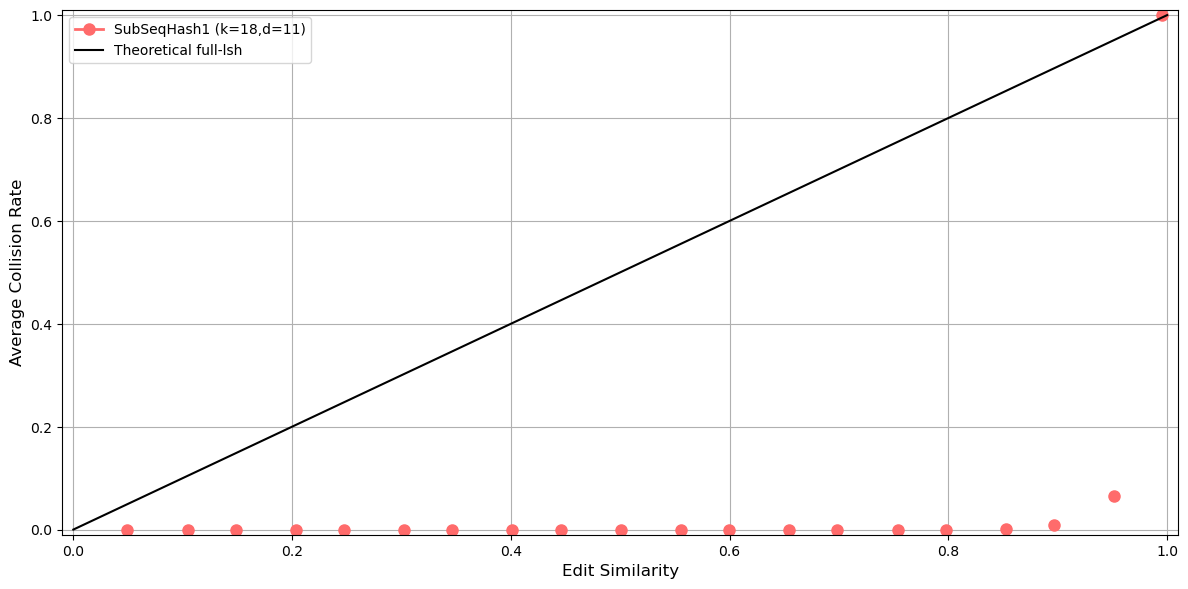

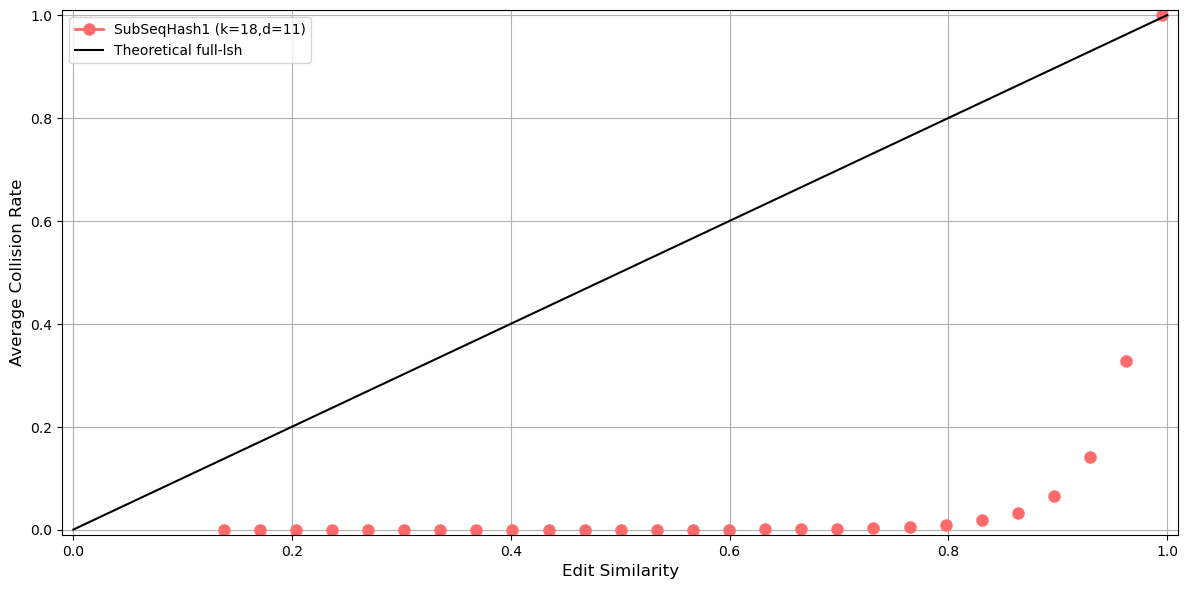

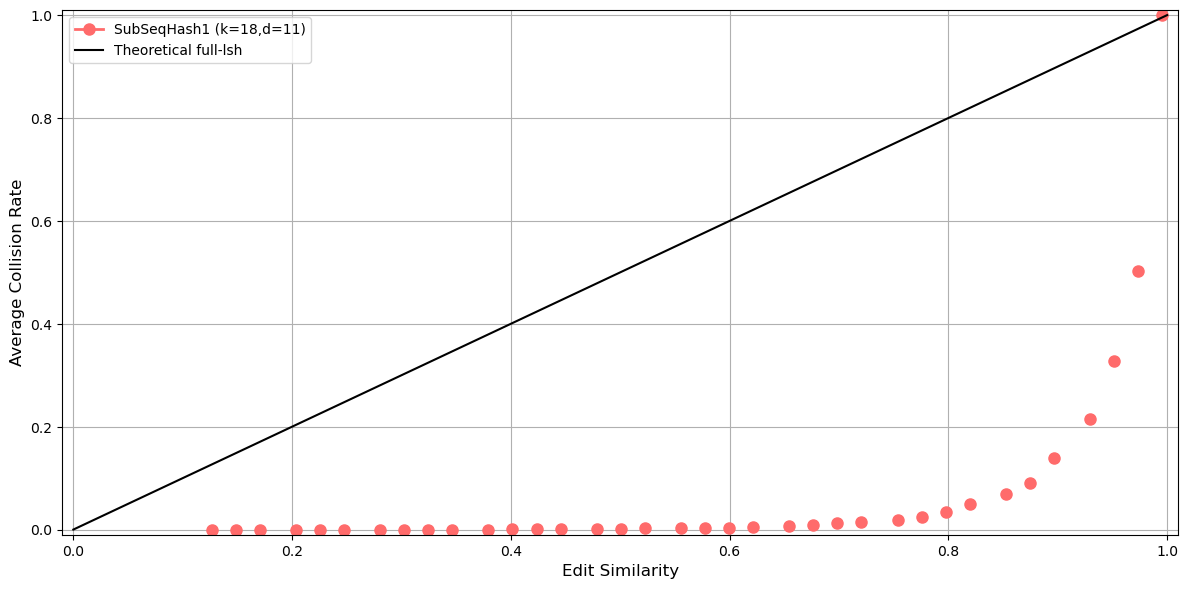

In [ ]:
for idx, row in df.iterrows():
    x_values = row['similarity_values']
    y_values = row['collision_rates']
    # bin the data into 100 bins

# Scatter Plot: Collision rate vs Angular Similarity for various hash families
plt.figure(figsize=(12, 6))
plt.ylabel(r"$\text{Collision rate}$", fontsize=15)
plt.xlabel(r'$\text{Similarity}$', fontsize=15)
plt.xlim(-0.01, 1.01)
plt.ylim(-0.01, 1.01)
plt.grid(visible=True, which="both", axis="both")

# Plot each hash family with different colors
idx = 0
for family_idx, num_bases in enumerate(list_of_hash_families):
    plt.scatter(
        AllAngularSimilarity,
        AllCollisionRate[:, family_idx],
        color=family_colors[family_idx],
        alpha=0.4,
        s=20,
        label = list_of_hash_families_labels[idx]
        # label=f"{num_bases}-base sampling"
    )
    idx += 1

# Add theoretical line
line_x = np.arange(0, 1.01, 0.01)
line_y = np.arange(0.5,1.005,0.005)
plt.plot(line_x, line_x, color="black", linewidth=1.5, alpha=1, label="Theoretical full-lsh")

plt.legend(fontsize=12, loc='upper left')
plt.tight_layout()
path = output_dir / "scatter_collisionrate_vs_sim_all_families.png"
plt.savefig(path, dpi=600)
# plt.show()
    

[0.45, 0.4, 0.45, 0.4, 0.8, 0.6, 0.3, 0.55, 0.45, 0.45, 0.85, 0.55, 0.3, 0.85, 0.4, 0.3, 1.0, 0.55, 0.45, 0.95, 1.0, 0.5, 0.8, 0.55, 0.35, 0.8, 0.9, 0.45, 0.75, 0.55, 0.65, 0.75, 0.5, 0.85, 0.4, 0.5, 0.7, 0.75, 1.0, 0.8, 0.5, 0.2, 0.35, 0.4, 0.75, 0.6, 0.2, 0.8, 0.15, 0.45, 0.65, 0.45, 0.3, 0.85, 0.45, 0.35, 0.15, 0.9, 0.65, 0.4, 0.9, 0.2, 0.85, 1.0, 0.65, 0.7, 0.6, 0.95, 0.9, 0.55, 0.75, 0.5, 0.45, 0.75, 0.45, 0.85, 0.6, 0.95, 0.5, 0.8, 0.25, 0.7, 0.3, 0.4, 0.5, 0.35, 0.75, 0.45, 0.05, 0.3, 0.35, 0.5, 0.4, 0.55, 0.45, 0.3, 1.0, 0.45, 0.65, 0.75, 0.4, 0.3, 0.4, 0.9, 0.45, 0.35, 0.25, 0.25, 0.25, 0.3, 0.45, 0.8, 0.9, 0.65, 0.4, 0.3, 0.25, 0.35, 0.25, 0.45, 0.25, 0.45, 0.5, 1.0, 0.95, 0.5, 0.9, 0.65, 0.3, 0.9, 0.95, 0.55, 0.55, 0.8, 0.3, 0.25, 0.3, 0.35, 0.9, 0.45, 0.95, 0.5, 0.3, 0.4, 1.0, 0.6, 0.95, 0.85, 0.45, 0.7, 0.5, 0.2, 0.9, 0.2, 0.85, 0.85, 0.25, 0.75, 0.3, 0.35, 0.5, 0.6, 0.2, 0.35, 0.7, 0.4, 0.6, 0.5, 0.3, 0.4, 0.35, 0.2, 0.4, 0.8, 0.95, 1.0, 0.7, 0.25, 0.3, 0.25, 0.9, 0.8, 0.

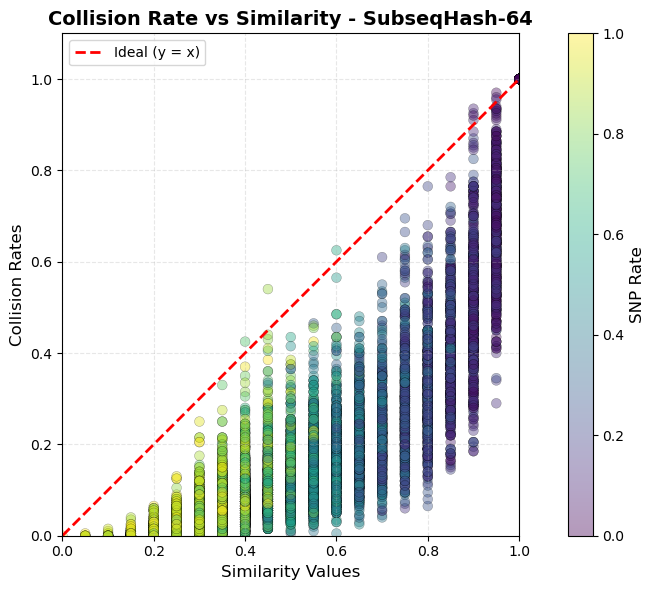

In [ ]:
for idx, row in df.iterrows():
    x_values = np.array(row['similarity_values'])
    y_values = np.array(row['collision_rates'])
    label_values = np.array(row['snp_rate'])
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Scatter plot with colorbar
    scatter = ax.scatter(x_values, y_values, c=label_values, cmap='viridis', 
                         alpha=0.4, edgecolors='black', linewidth=0.3, s=50)
    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label('SNP Rate', fontsize=12)
    
    # Ideal line
    ax.plot([0, 1], [0, 1], 'r--', linewidth=2, label='Ideal (y = x)')
    
    # Axis settings
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1.1)
    ax.set_xlabel('Similarity Values', fontsize=12)
    ax.set_ylabel('Collision Rates', fontsize=12)
    ax.set_title(f"Collision Rate vs Similarity - {row['hashname']}", fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.legend(loc='upper left')
    ax.set_aspect('equal', adjustable='box')  # Square aspect ratio
    
    plt.tight_layout()
    plt.savefig(f"/home/dynamics/bikram/BioHasher/results/{row['hashname']}_scatter.png", dpi=150)
    plt.show()

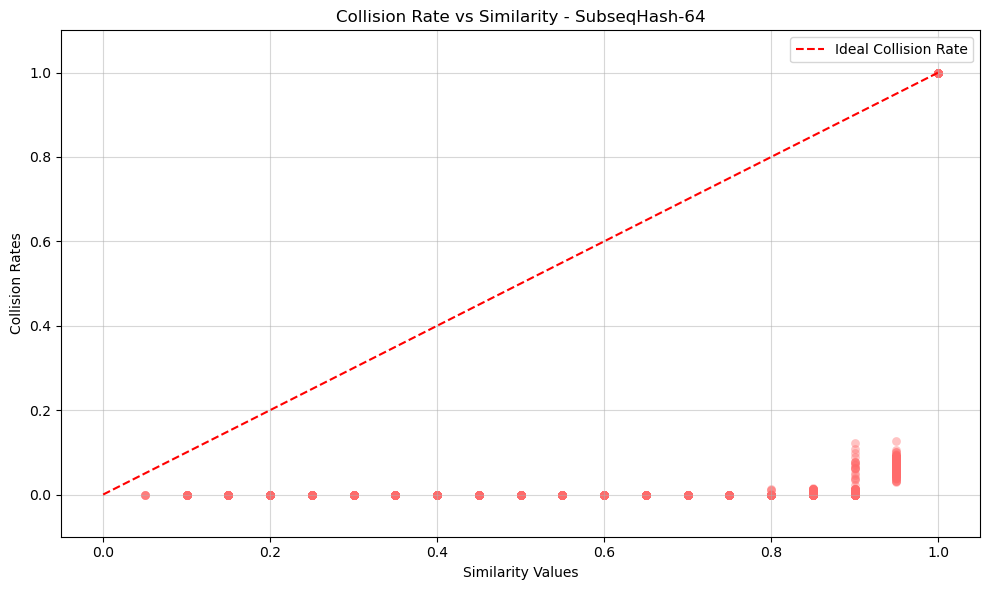

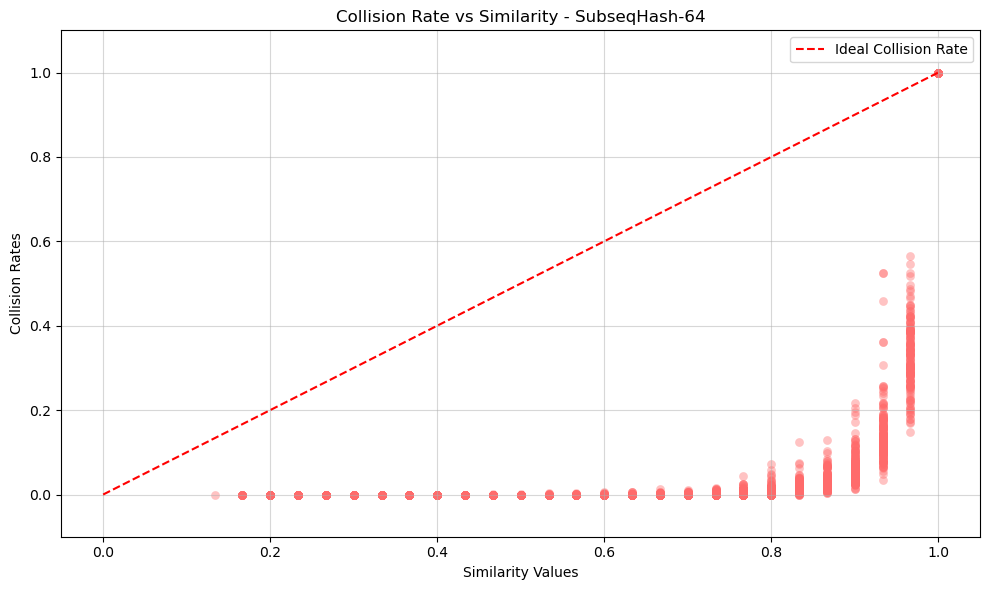

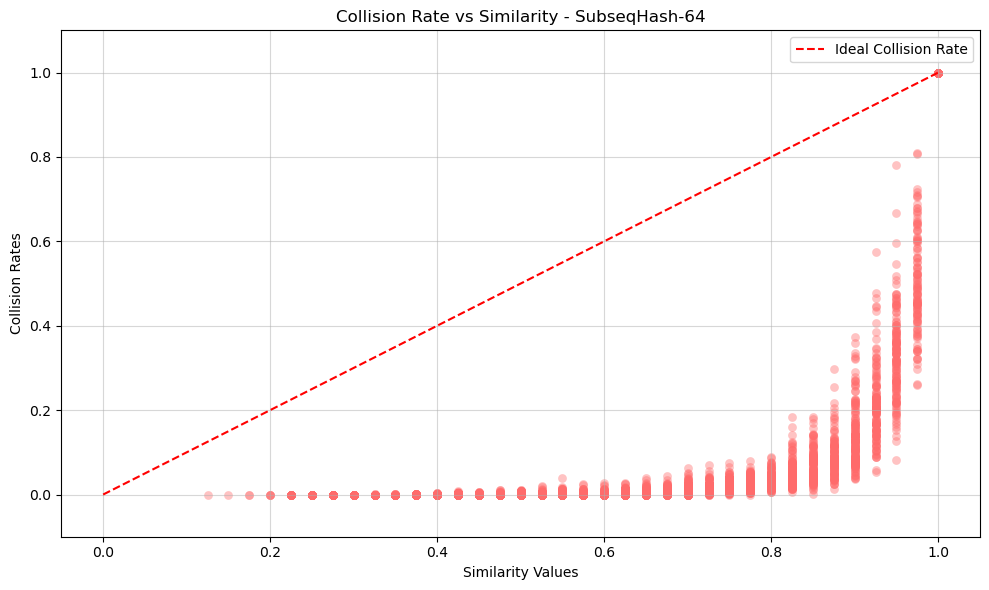

In [25]:
    # family_colors = ['#FF6B6B', '#4ECDC4', '#FFA07A']
for idx, row in df.iterrows():
    x_values = row['similarity_values']
    y_values = row['collision_rates']
    label_values = row['snp_rate']
    plt.figure(figsize=(10, 6))
    plt.ylim(-0.1, 1.1)
    plt.grid(True, alpha=0.5)
    plt.scatter(x_values, y_values, alpha=0.4,c='#FF6B6B', linewidth=0.2)
    plt.xlabel('Similarity Values')
    plt.ylabel('Collision Rates')
    plt.title(f"Collision Rate vs Similarity - {row['hashname']}")
    plt.plot([0.0, 1], [0.0, 1], 'r--', label='Ideal Collision Rate')
    plt.legend()
    
    plt.tight_layout()
    plt.show()

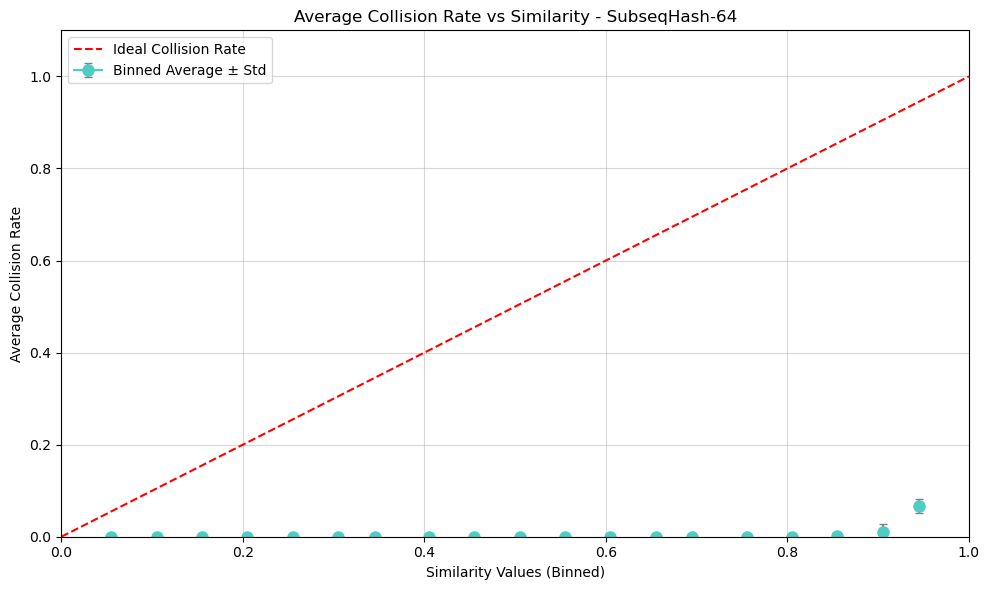

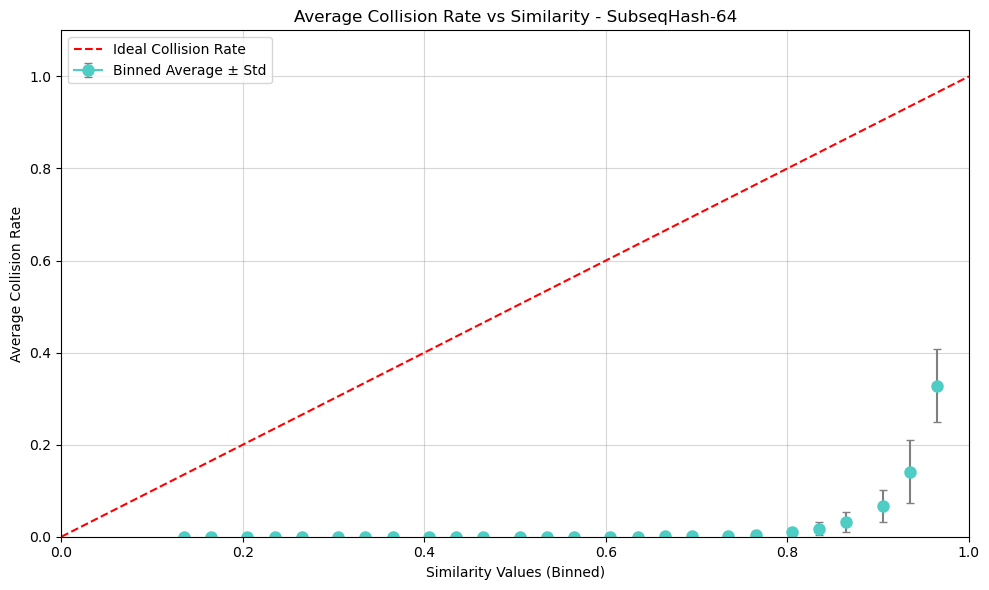

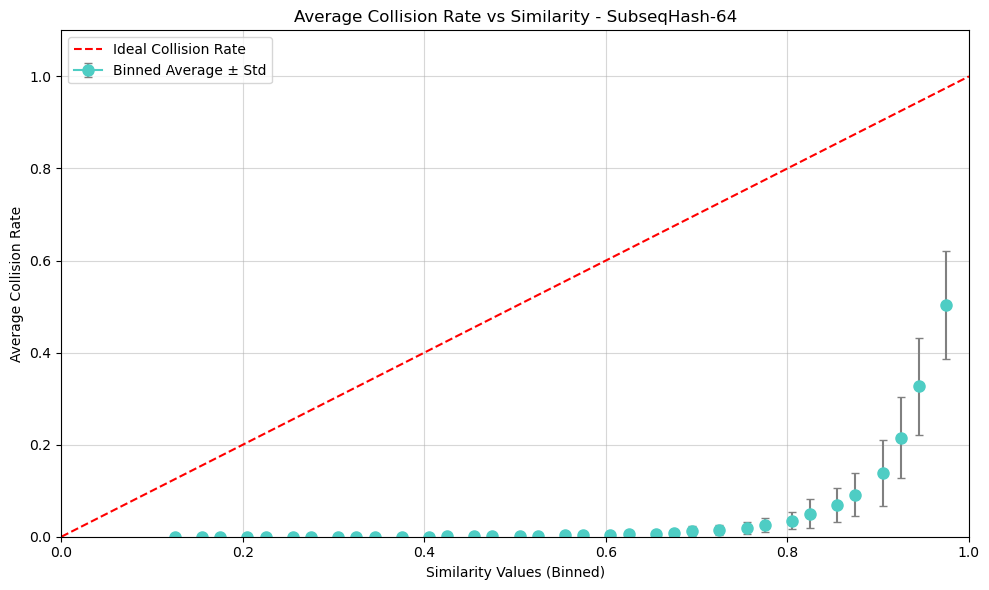

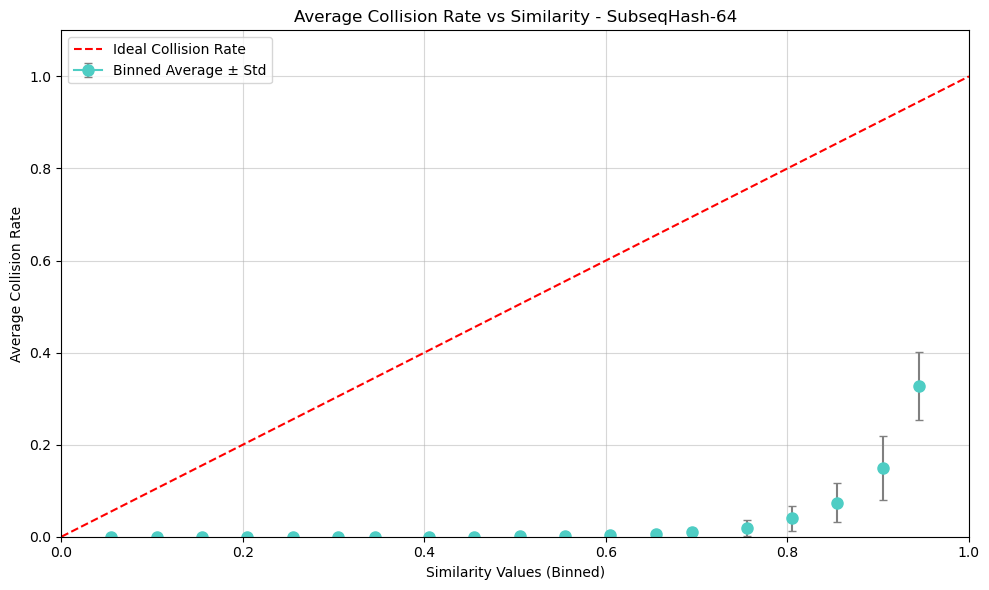

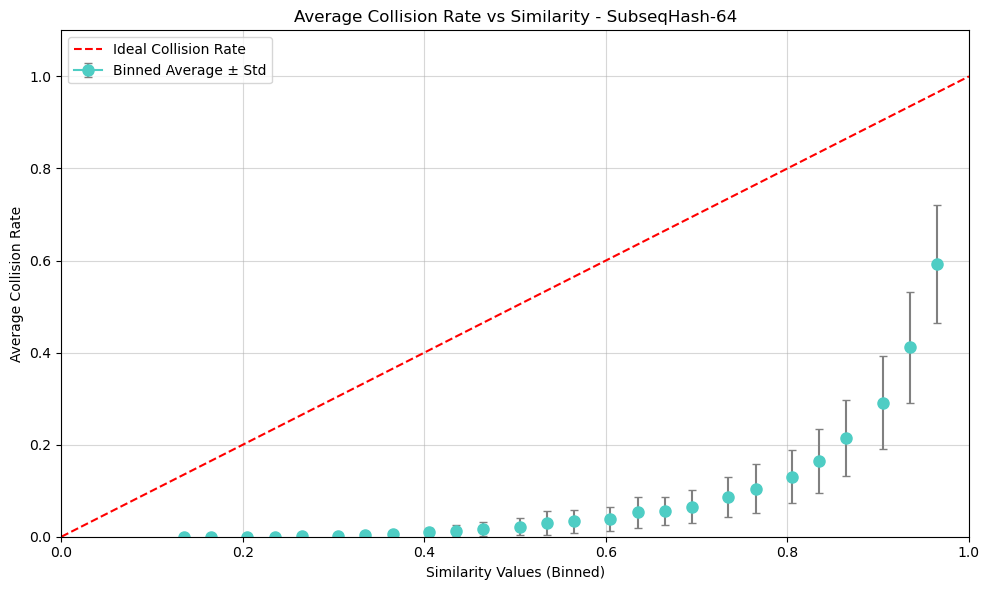

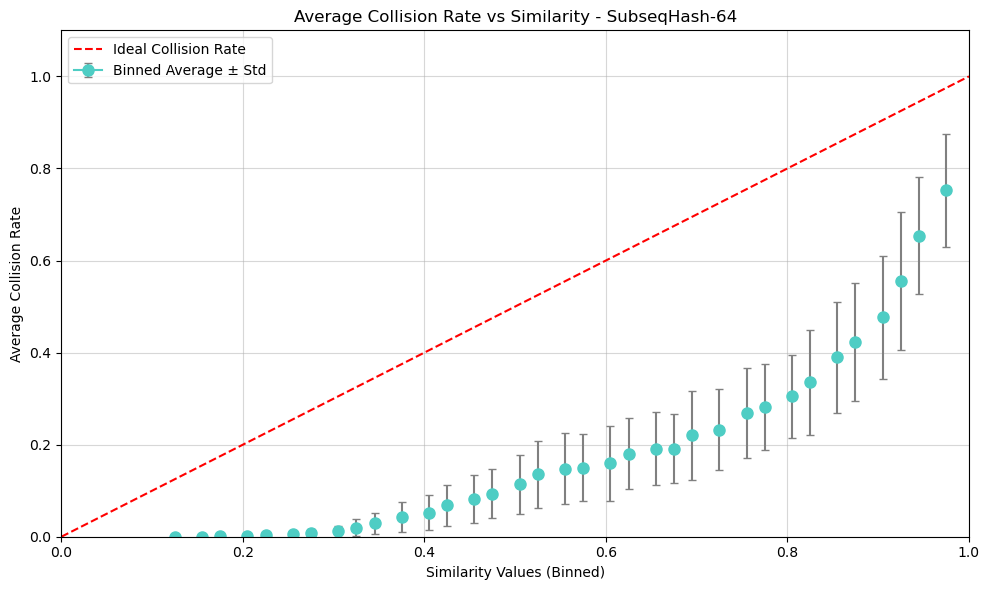

In [45]:
# Cell #VSC-9fa56913

for idx, row in df.iterrows():
    x_values = np.array(row['similarity_values'])
    y_values = np.array(row['collision_rates'])
    
    # Define bins (e.g., 20 bins from 0 to 1)
    num_bins = 100
    bin_edges = np.linspace(0, 1, num_bins + 1)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
    # Compute mean and std for each bin
    bin_means = []
    bin_stds = []
    bin_counts = []
    
    for i in range(num_bins):
        mask = (x_values >= bin_edges[i]) & (x_values < bin_edges[i + 1])
        if mask.sum() > 0:
            bin_means.append(np.mean(y_values[mask]))
            bin_stds.append(np.std(y_values[mask]))
            bin_counts.append(mask.sum())
        else:
            bin_means.append(np.nan)
            bin_stds.append(np.nan)
            bin_counts.append(0)
    
    bin_means = np.array(bin_means)
    bin_stds = np.array(bin_stds)
    
    # Plot
    plt.figure(figsize=(10, 6))
    plt.ylim(0, 1.1)
    plt.xlim(0, 1)
    plt.grid(True, alpha=0.5)
    
    # Plot average with error bars (std deviation)
    plt.errorbar(bin_centers, bin_means, yerr=bin_stds, fmt='o-', 
                 color='#4ECDC4', ecolor='gray', capsize=3, 
                 label='Binned Average ± Std', markersize=8)
    
    # Ideal line
    plt.plot([0, 1], [0, 1], 'r--', label='Ideal Collision Rate')
    
    plt.xlabel('Similarity Values (Binned)')
    plt.ylabel('Average Collision Rate')
    plt.title(f"Average Collision Rate vs Similarity - {row['hashname']}")
    plt.legend()
    plt.tight_layout()
    plt.show()

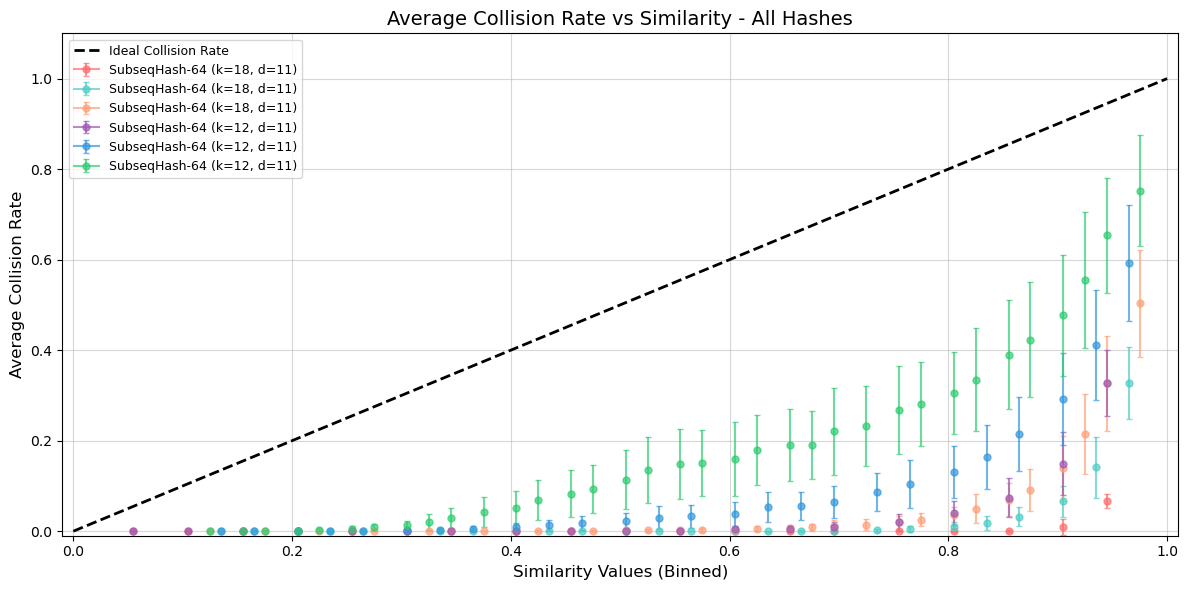

In [46]:
# Cell #VSC-4d8fa2be

# Define colors for different rows
colors = ['#FF6B6B', '#4ECDC4', '#FFA07A', '#9B59B6', '#3498DB', '#2ECC71', '#E74C3C', '#1ABC9C']

# Create single figure
plt.figure(figsize=(12, 6))

for idx, row in df.iterrows():
    x_values = np.array(row['similarity_values'])
    y_values = np.array(row['collision_rates'])
    
    # Define bins
    num_bins = 100
    bin_edges = np.linspace(0, 1, num_bins + 1)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
    # Compute mean and std for each bin
    bin_means = []
    bin_stds = []
    
    for i in range(num_bins):
        mask = (x_values >= bin_edges[i]) & (x_values < bin_edges[i + 1])
        if mask.sum() > 0:
            bin_means.append(np.mean(y_values[mask]))
            bin_stds.append(np.std(y_values[mask]))
        else:
            bin_means.append(np.nan)
            bin_stds.append(np.nan)
    
    bin_means = np.array(bin_means)
    bin_stds = np.array(bin_stds)
    
    # Create label from row data
    label = f"{row['hashname']} (k={row['SubseqHash_k']}, d={row['SubseqHash_d']})"
    
    # Plot with error bars
    plt.errorbar(bin_centers, bin_means, yerr=bin_stds, fmt='o-', 
                 color=colors[idx % len(colors)], ecolor=colors[idx % len(colors)], 
                 alpha=0.7, capsize=2, markersize=5, linewidth=1.5, label=label)

# Ideal line
plt.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Ideal Collision Rate')

# Styling
plt.ylim(-0.01, 1.1)
plt.xlim(-0.01, 1.01)
plt.grid(True, alpha=0.5)
plt.xlabel('Similarity Values (Binned)', fontsize=12)
plt.ylabel('Average Collision Rate', fontsize=12)
plt.title('Average Collision Rate vs Similarity - All Hashes', fontsize=14)
plt.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig("/home/dynamics/bikram/BioHasher/results/all_hashes_errorbar.png", dpi=150)
plt.show()

In [38]:
df.drop(df[df['sequencelength'] == 40].index, inplace=True)
df.drop(df[df['sequencelength'] == 20].index, inplace=True)


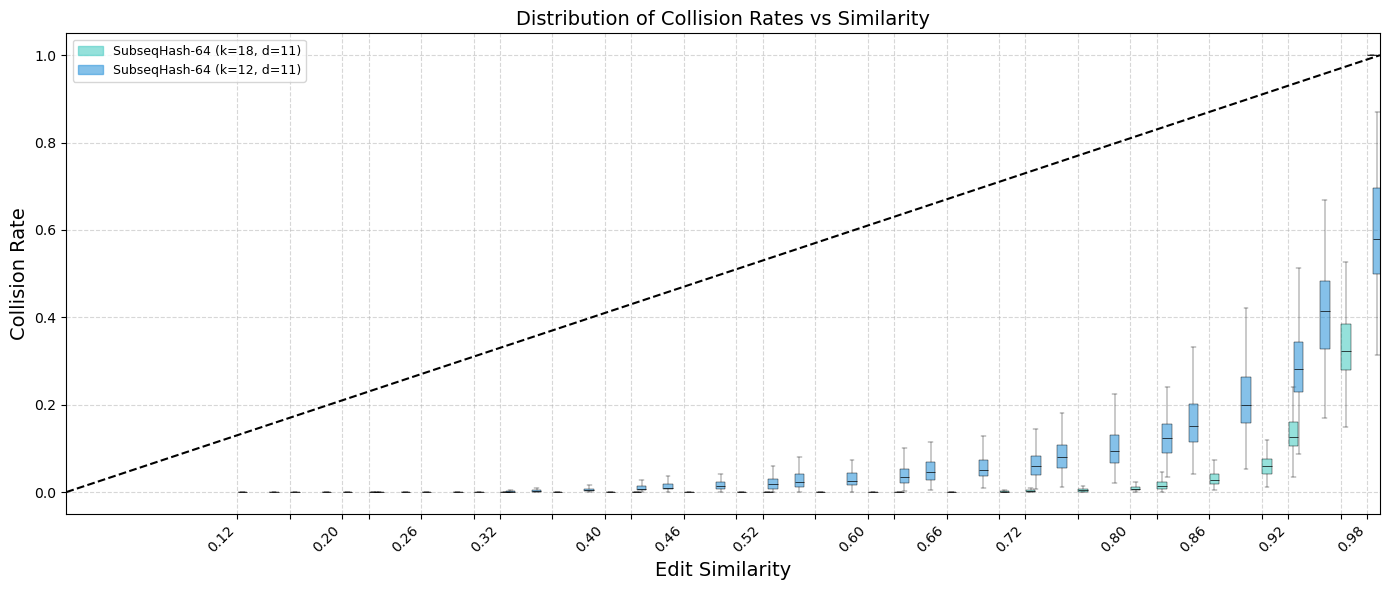

In [39]:
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors

# Define colors for different rows
colors = ['#FF6B6B', '#4ECDC4', '#FFA07A', '#9B59B6', '#3498DB', '#2ECC71', '#E74C3C', '#1ABC9C']

# Box Plot of collision rate vs Similarity for various hash configurations
fig, ax = plt.subplots(figsize=(14, 6))

# Store valid positions from first iteration for consistent x-axis
first_valid_positions = None
first_labels = None

for idx, row in df.iterrows():
    x_values = np.array(row['similarity_values'])
    y_values = np.array(row['collision_rates'])
    
    # Define bins
    num_bins = 50  # Reduced for cleaner boxplots
    bin_edges = np.linspace(0, 1, num_bins + 1)
    
    # Bin the collision rates
    binned_collision_rates = [[] for _ in range(num_bins)]
    
    for i in range(len(x_values)):
        sim_value = x_values[i]
        collision_value = y_values[i]
        # Find the appropriate bin
        bin_idx = int(sim_value * num_bins)
        if bin_idx >= num_bins:
            bin_idx = num_bins - 1
        binned_collision_rates[bin_idx].append(collision_value)
    
    # Convert to format suitable for boxplot (filter empty bins)
    collision_data = []
    valid_positions = []
    valid_similarities = []
    
    for i, bin_data in enumerate(binned_collision_rates):
        if len(bin_data) > 0:
            collision_data.append(bin_data)
            valid_positions.append(i + 1)
            valid_similarities.append(bin_edges[i])
    
    # Store first iteration's positions for consistent labeling
    if first_valid_positions is None:
        first_valid_positions = valid_positions.copy()
        # Create labels
        first_labels = []
        step_size = max(1, len(valid_similarities) // 10)
        for i in range(len(valid_similarities)):
            if i % step_size == 0:
                first_labels.append(f"{valid_similarities[i]:.2f}")
            else:
                first_labels.append("")
    
    # Calculate offset for each row to space them out
    num_rows = len(df)
    box_width = 0.8 / num_rows
    offset = (idx - (num_rows - 1) / 2) * box_width
    offset_positions = [p + offset for p in valid_positions]
    
    bp_h = ax.boxplot(
        collision_data,
        positions=offset_positions,
        widths=box_width * 0.9,
        patch_artist=True,
        showfliers=False
    )
    
    current_color = colors[idx % len(colors)]
    rgba_color = mcolors.to_rgba(current_color, alpha=0.6)
    
    # Color boxes
    for box in bp_h['boxes']:
        box.set_facecolor(rgba_color)
        box.set_edgecolor("black")
        box.set_linewidth(0.3)
    
    # Style medians, whiskers, caps
    for median in bp_h['medians']:
        median.set_color("black")
        median.set_linewidth(0.5)
    for w in bp_h['whiskers']:
        w.set_color("black")
        w.set_linewidth(0.3)
    for cap in bp_h['caps']:
        cap.set_color("black")
        cap.set_linewidth(0.3)

# Create combined legend
patches = [
    mpatches.Patch(color=colors[idx % len(colors)], 
                   label=f"{row['hashname']} (k={row['SubseqHash_k']}, d={row['SubseqHash_d']})", 
                   alpha=0.6)
    for idx, row in df.iterrows()
]

ax.legend(handles=patches, fontsize=9, loc='upper left')

ax.set_xlabel(similarity, fontsize=14)
ax.set_ylabel('Collision Rate', fontsize=14)
ax.set_title('Distribution of Collision Rates vs Similarity', fontsize=14)

# Set x-ticks
ax.set_xticks(first_valid_positions)
ax.set_xticklabels(first_labels, rotation=45, ha='right')

ax.grid(True, linestyle='--', alpha=0.5)
ax.set_xlim(0.5, max(first_valid_positions) + 0.5)
ax.set_ylim(-0.05, 1.05)

# Add ideal line
ax.plot([0.5, max(first_valid_positions) + 0.5], 
        [0, 1], 'k--', linewidth=1.5, label='Ideal')

fig.tight_layout()
plt.savefig("boxplot_collision_vs_similarity.png", dpi=300)
plt.show()